In [1]:
from utils import *

In [2]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter
from typing import Pattern

from utils import *

# Parser
POC_DIR = Path("/Users/hyeon/SeSAC_Project/PoC")    # PoC의 절대경로 입력
RUN_FOLDER = "test7"
RUN_DIR = POC_DIR / "run" / RUN_FOLDER

# 루트 디렉토리 바로 아래의 pose_predictions.json 지정
OUTPUTS_DIR = RUN_DIR / "outputs"

user = RUN_DIR / "user_info.json"
with user.open(mode="r", encoding='utf-8') as file:
    user_data = json.load(file)

hpe = OUTPUTS_DIR / "pose_predictions.json"
with hpe.open(mode="r", encoding='utf-8') as file:
    pose_data = json.load(file)

details = OUTPUTS_DIR / "details.json"
with details.open(mode="r", encoding='utf-8') as file:
    detail_data = json.load(file)

ps = PoseSequence(pose_data, detail_data, user_data)

# 피처 추출을 위한 값 계산
ps.cal_stride()
ps.pixel2m()

사용자의 키를 기반으로 계산한 픽셀당 meter는 0.0025383889813480466 / pixel 입니다.


In [3]:
help(np.arctan2)

Help on ufunc in module numpy:

arctan2 = <ufunc 'arctan2'>
    arctan2(x1, x2, /, out=None, *, where=True, casting='same_kind', order='K', dtype=None, subok=True[, signature])

    Element-wise arc tangent of ``x1/x2`` choosing the quadrant correctly.

    The quadrant (i.e., branch) is chosen so that ``arctan2(x1, x2)`` is
    the signed angle in radians between the ray ending at the origin and
    passing through the point (1,0), and the ray ending at the origin and
    passing through the point (`x2`, `x1`).  (Note the role reversal: the
    "`y`-coordinate" is the first function parameter, the "`x`-coordinate"
    is the second.)  By IEEE convention, this function is defined for
    `x2` = +/-0 and for either or both of `x1` and `x2` = +/-inf (see
    Notes for specific values).

    This function is not defined for complex-valued arguments; for the
    so-called argument of complex values, use `angle`.

    Parameters
    ----------
    x1 : array_like, real-valued
        `y`-co

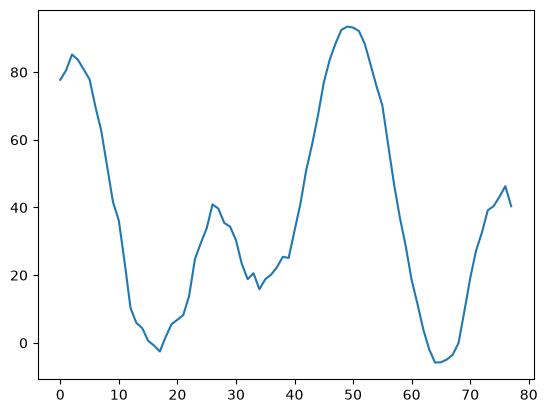

In [5]:
plt.plot(ps.joint_angle("left_knee", negative=True))